In [1]:

# Import necessary libraries#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Load the dataset
data = pd.read_csv('/kaggle/input/optiver-training-data/train.csv')

In [3]:
# Display basic information about the dataset
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5237980 entries, 0 to 5237979
Data columns (total 17 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   stock_id                 int64  
 1   date_id                  int64  
 2   seconds_in_bucket        int64  
 3   imbalance_size           float64
 4   imbalance_buy_sell_flag  int64  
 5   reference_price          float64
 6   matched_size             float64
 7   far_price                float64
 8   near_price               float64
 9   bid_price                float64
 10  bid_size                 float64
 11  ask_price                float64
 12  ask_size                 float64
 13  wap                      float64
 14  target                   float64
 15  time_id                  int64  
 16  row_id                   object 
dtypes: float64(11), int64(5), object(1)
memory usage: 679.4+ MB
None


In [4]:
data.shape

(5237980, 17)

In [5]:
# Display the first few rows of the dataset
print(data.head())

   stock_id  date_id  seconds_in_bucket  imbalance_size  \
0         0        0                  0      3180602.69   
1         1        0                  0       166603.91   
2         2        0                  0       302879.87   
3         3        0                  0     11917682.27   
4         4        0                  0       447549.96   

   imbalance_buy_sell_flag  reference_price  matched_size  far_price  \
0                        1         0.999812   13380276.64        NaN   
1                       -1         0.999896    1642214.25        NaN   
2                       -1         0.999561    1819368.03        NaN   
3                       -1         1.000171   18389745.62        NaN   
4                       -1         0.999532   17860614.95        NaN   

   near_price  bid_price  bid_size  ask_price   ask_size  wap    target  \
0         NaN   0.999812  60651.50   1.000026    8493.03  1.0 -3.029704   
1         NaN   0.999896   3233.04   1.000660   20605.09  1.0 

In [6]:
# Check for missing values
print(data.isnull().sum())

stock_id                         0
date_id                          0
seconds_in_bucket                0
imbalance_size                 220
imbalance_buy_sell_flag          0
reference_price                220
matched_size                   220
far_price                  2894342
near_price                 2857180
bid_price                      220
bid_size                         0
ask_price                      220
ask_size                         0
wap                            220
target                          88
time_id                          0
row_id                           0
dtype: int64


In [7]:
# Drop rows with missing values in the 'target' column
data.dropna(subset=['target'], inplace=True)

In [8]:
# Check for missing values in the 'target' column after dropping
print(data['target'].isnull().sum())

0


In [9]:
 #Dictionary to store filling values for each column
fill_values = {
    'imbalance_size': 0,
    'reference_price': data['reference_price'].median(),
    'bid_price': data['bid_price'].median(),
    'ask_price': data['ask_price'].median(),
    'matched_size': data['matched_size'].mean(),
    'far_price': data['far_price'].mean(),
    'near_price': data['near_price'].mean()
}

# Apply the filling values to the corresponding columns
data = data.fillna(fill_values)

# Check for missing values after replacement
print("Missing values after replacing:")
print(data.isnull().sum())

Missing values after replacing:
stock_id                     0
date_id                      0
seconds_in_bucket            0
imbalance_size               0
imbalance_buy_sell_flag      0
reference_price              0
matched_size                 0
far_price                    0
near_price                   0
bid_price                    0
bid_size                     0
ask_price                    0
ask_size                     0
wap                        132
target                       0
time_id                      0
row_id                       0
dtype: int64


In [10]:
#replacing nan values for WAP

data['wap'] = data.apply(lambda row: ((row['bid_price']* row['ask_size']) + (row['ask_price'] * row['bid_size'])) /
                                                (row['bid_size'] + row['ask_size'])
    if pd.isna(row['wap'])
    else row['wap'], axis=1)

# Check for missing values after replacement
print("Missing values after replacing with 0:")
print(data.isnull().sum())


Missing values after replacing with 0:
stock_id                   0
date_id                    0
seconds_in_bucket          0
imbalance_size             0
imbalance_buy_sell_flag    0
reference_price            0
matched_size               0
far_price                  0
near_price                 0
bid_price                  0
bid_size                   0
ask_price                  0
ask_size                   0
wap                        0
target                     0
time_id                    0
row_id                     0
dtype: int64


In [11]:
#Memory Reduction Code

def reduce_memory_usage(df):
    start_memory = df.memory_usage().sum() / 1024**2  # Memory usage in MB

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_memory = df.memory_usage().sum() / 1024**2  # Memory usage after reduction
    print(f"Memory usage reduced from {start_memory:.2f} MB to {end_memory:.2f} MB")

    return df



In [12]:
# 'data' is our DataFrame
data = reduce_memory_usage(data)


Memory usage reduced from 719.32 MB to 423.72 MB


In [13]:
data.shape

(5237892, 17)

In [14]:
#pip install tensorflow

In [15]:
correlation_matrix = data.corr()

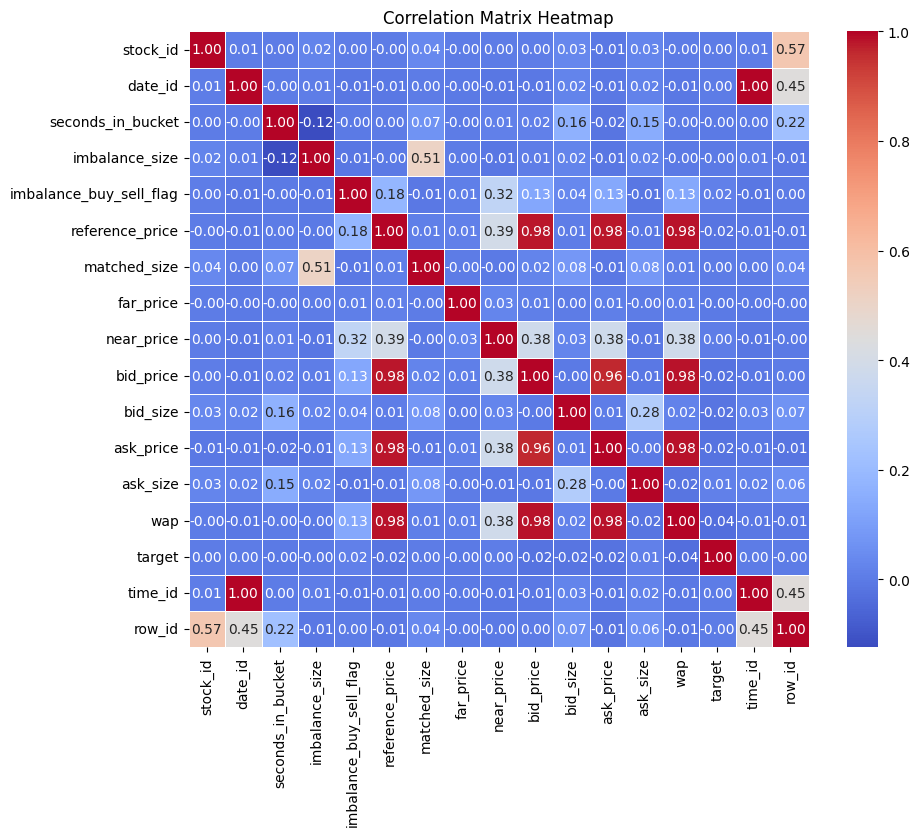

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'correlation_matrix' is your correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 10})
plt.title("Correlation Matrix Heatmap")
plt.show()


In [17]:
pip install keras-tuner


Note: you may need to restart the kernel to use updated packages.


In [18]:
import keras_tuner as kt


In [19]:
# #!pip install xgboost
# !pip install optuna


Trial 5 Complete [00h 25m 44s]
val_loss: 0.006974417250603437

Best val_loss So Far: 0.0018676052568480372
Total elapsed time: 02h 07m 36s
Epoch 1/50
8185/8185 [==============================] - 308s 36ms/step - loss: 0.0075 - val_loss: 0.0055
Epoch 2/50
8185/8185 [==============================] - 302s 36ms/step - loss: 9.3995e-04 - val_loss: 0.0043
Epoch 3/50
8185/8185 [==============================] - 305s 37ms/step - loss: 3.6093e-04 - val_loss: 0.0048
Epoch 4/50
8185/8185 [==============================] - 301s 36ms/step - loss: 2.3792e-04 - val_loss: 0.0038
Epoch 5/50
8185/8185 [==============================] - 302s 36ms/step - loss: 1.9393e-04 - val_loss: 0.0037
Epoch 6/50
8185/8185 [==============================] - 303s 36ms/step - loss: 1.3896e-04 - val_loss: 0.0039
Epoch 7/50
8185/8185 [==============================] - 306s 37ms/step - loss: 1.4367e-04 - val_loss: 0.0037
Epoch 8/50
8185/8185 [==============================] - 303s 36ms/step - loss: 1.1287e-04 - val_loss: 

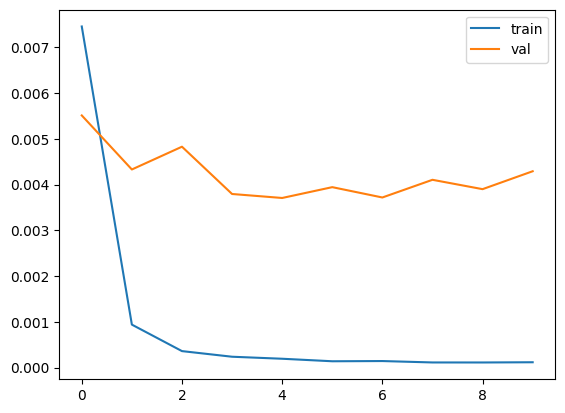

2047/2047 [==============================] - 10s 4ms/step
Mean Absolute Error: 17048266.87096748


In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters
import matplotlib.pyplot as plt
import tensorflow as tf

# Load your data
# Assuming your data is a pandas DataFrame with the target variable in the last column
# Modify this part according to your data loading logic
# data = pd.read_csv("your_data.csv")

# Function to prepare data for LSTM
def prepare_data(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data.iloc[i:(i + time_steps), :-1].values)
        y.append(data.iloc[i + time_steps, -1])
    return np.array(X), np.array(y)

# Scale the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Define the number of time steps (look-back)
time_steps = 5

# Prepare data for LSTM
X, y = prepare_data(pd.DataFrame(scaled_data), time_steps)

# Split the data into training and testing sets explicitly based on time
train_size = int(len(X) * 0.8)
X_train, X_test, y_train, y_test = X[:train_size], X[train_size:], y[:train_size], y[train_size:]

# Use tf.data for better performance
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(buffer_size=len(X_train)).batch(512)
val_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(512)

# Define the LSTM model
def build_model(hp):
    model = tf.keras.Sequential()
    for _ in range(hp.Int('num_layers', 1, 3)):
        model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(hp.Int('units', 50, 100), activation=hp.Choice('activation', ['tanh', 'sigmoid']), return_sequences=True, input_shape=(time_steps, X_train.shape[2]))))
        model.add(tf.keras.layers.Dropout(hp.Float('dropout', 0.2, 0.5)))
    model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(hp.Int('units', 50, 100), activation=hp.Choice('activation', ['tanh', 'sigmoid']))))
    model.add(tf.keras.layers.Dense(1, activation='linear'))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-2)), loss='mse')
    return model

# Instantiate the tuner
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,  # Reduced the number of trials
    executions_per_trial=1,
    directory='my_dir',
    project_name='lstm_hyperparam_tuning'
)

# Early stopping callback for tuner
tuner_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Perform the hyperparameter search with fewer epochs
tuner.search(train_dataset, epochs=5, validation_data=val_dataset, callbacks=[tuner_cb])

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Create the final model with the best hyperparameters
final_model = tuner.hypermodel.build(best_hps)

# Early stopping callback for final model
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the final model using tf.data with more epochs
history = final_model.fit(train_dataset, epochs=50, validation_data=val_dataset, callbacks=[early_stopping])

# Plot training history
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

# Make predictions on the test set using tf.data
y_pred = final_model.predict(val_dataset)

# Inverse transform the scaled predictions and target values
# Assuming X_test has shape (batch_size, time_steps, features)
X_test_last_step = X_test[:, -1, :].reshape(-1, X_test.shape[2])  # Extracting the last time step
y_pred = scaler.inverse_transform(np.hstack((X_test_last_step, y_pred.reshape(-1, 1))))[:, -1]
y_true = scaler.inverse_transform(np.hstack((X_test_last_step, y_test.reshape(-1, 1))))[:, -1]

# Compute Mean Absolute Error
mae = mean_absolute_error(y_true, y_pred)
print(f'Mean Absolute Error: {mae}')


In [21]:
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.metrics import mean_absolute_error
# from kerastuner.tuners import RandomSearch
# from kerastuner.engine.hyperparameters import HyperParameters
# import matplotlib.pyplot as plt
# import tensorflow as tf
# import pandas as pd
# import numpy as np

# # Load your data
# # Assuming your data is a pandas DataFrame with the target variable in the last column
# # Modify this part according to your data loading logic
# # data = pd.read_csv("your_data.csv")

# # Function to prepare data for LSTM
# def prepare_data(data, time_steps):
#     X, y = [], []
#     for i in range(len(data) - time_steps):
#         X.append(data.iloc[i:(i + time_steps), :-1].values)
#         y.append(data.iloc[i + time_steps, -1])
#     return np.array(X), np.array(y)

# # Scale the data
# scaler = MinMaxScaler()
# scaled_data = scaler.fit_transform(data)

# # Define the number of time steps (look-back)
# time_steps = 5

# # Prepare data for LSTM
# X, y = prepare_data(pd.DataFrame(scaled_data), time_steps)

# # Split the data into training and testing sets explicitly based on time
# train_size = int(len(X) * 0.8)
# X_train, X_test, y_train, y_test = X[:train_size], X[train_size:], y[:train_size], y[train_size:]

# # Use tf.data for better performance
# train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(buffer_size=len(X_train)).batch(512)
# val_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(512)

# # Define the LSTM model
# def build_model(hp):
#     model = tf.keras.Sequential()
#     for _ in range(hp.Int('num_layers', 1, 3)):
#         model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(hp.Int('units', 50, 200), activation='tanh', return_sequences=True, input_shape=(time_steps, X_train.shape[2]))))
#         model.add(tf.keras.layers.Dropout(hp.Float('dropout', 0.2, 0.5)))
#     model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(hp.Int('units', 50, 200), activation='tanh')))
#     model.add(tf.keras.layers.Dense(1, activation='linear'))
#     model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-2)), loss='mse')
#     return model

# # Instantiate the tuner
# tuner = RandomSearch(
#     build_model,
#     objective='val_loss',
#     max_trials=10,  # You can increase this
#     executions_per_trial=1,
#     directory='my_dir',
#     project_name='lstm_hyperparam_tuning'
# )

# # Perform the hyperparameter search
# tuner.search(train_dataset, epochs=10, validation_data=val_dataset)

# # Get the best hyperparameters
# best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# # Create the final model with the best hyperparameters
# final_model = tuner.hypermodel.build(best_hps)

# # Early stopping callback
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# # Train the final model using tf.data
# history = final_model.fit(train_dataset, epochs=50, validation_data=val_dataset, callbacks=[early_stopping])

# # Plot training history
# plt.plot(history.history['loss'], label='train')
# plt.plot(history.history['val_loss'], label='val')
# plt.legend()
# plt.show()

# # Make predictions on the test set using tf.data
# y_pred = final_model.predict(val_dataset)

# # Inverse transform the scaled predictions and target values
# # Assuming X_test has shape (batch_size, time_steps, features)
# X_test_last_step = X_test[:, -1, :].reshape(-1, X_test.shape[2])  # Extracting the last time step
# y_pred = scaler.inverse_transform(np.hstack((X_test_last_step, y_pred.reshape(-1, 1))))[:, -1]
# y_true = scaler.inverse_transform(np.hstack((X_test_last_step, y_test.reshape(-1, 1))))[:, -1]

# # Compute Mean Absolute Error
# mae = mean_absolute_error(y_true, y_pred)
# print(f'Mean Absolute Error: {mae}')


In [22]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.metrics import mean_absolute_error
# from sklearn.model_selection import train_test_split
# import xgboost as xgb
# import optuna

# # Assuming your data is a pandas DataFrame with the target variable in the last column
# # Modify this part according to your data loading logic
# # data = pd.read_csv("your_data.csv")

# # Function to prepare data for XGBoost
# def prepare_data_xgboost(data, time_steps):
#     X, y = [], []
#     for i in range(len(data) - time_steps):
#         X.append(data.iloc[i:(i + time_steps), :-1].values.flatten())  # Flatten the input features
#         y.append(data.iloc[i + time_steps, -1])
#     return np.array(X), np.array(y)

# # Scale the data
# scaler = MinMaxScaler()
# scaled_data = scaler.fit_transform(data)

# # Define the number of time steps (look-back)
# time_steps = 5

# # Prepare data for XGBoost
# X, y = prepare_data_xgboost(pd.DataFrame(scaled_data), time_steps)

# # Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# # XGBoost hyperparameter tuning with Optuna
# def objective(trial, X_train, y_train, X_val, y_val):
#     params = {
#         'objective': 'reg:squarederror',
#         'booster': trial.suggest_categorical('booster', ['gbtree', 'gblinear']),
#         'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
#         'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
#         'max_depth': trial.suggest_int('max_depth', 1, 20),
#         'eta': trial.suggest_float('eta', 1e-8, 1.0, log=True),
#         'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
#         'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide'])
#     }

#     dtrain = xgb.DMatrix(X_train, label=y_train)
#     dval = xgb.DMatrix(X_val, label=y_val)

#     bst = xgb.train(params, dtrain)
#     y_pred = bst.predict(dval)

#     mae = mean_absolute_error(y_val, y_pred)
#     return mae

# # Split the training data further into training and validation sets
# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

# # Define the Optuna study
# study = optuna.create_study(direction='minimize')
# study.optimize(lambda trial: objective(trial, X_train, y_train, X_val, y_val), n_trials=10)

# # Get the best hyperparameters
# best_params = study.best_params

# # Train the final XGBoost model with the best hyperparameters
# final_model = xgb.train(best_params, xgb.DMatrix(X_train, label=y_train))

# # Make predictions on the test set
# dtest = xgb.DMatrix(X_test)
# y_pred = final_model.predict(dtest)

# # Inverse transform the scaled predictions and target values
# X_test_last_step = X_test[:, -1].reshape(-1, 1, X_test.shape[1])  # Extracting the last time step

# y_pred = scaler.inverse_transform(np.concatenate((X_test_last_step.reshape(-1, X_test_last_step.shape[2]), y_pred.reshape(-1, 1)), axis=1))[:, -1]
# y_true = scaler.inverse_transform(np.concatenate((X_test_last_step.reshape(-1, X_test_last_step.shape[2]), y_test.reshape(-1, 1)), axis=1))[:, -1]

# # Compute Mean Absolute Error
# mae = mean_absolute_error(y_true, y_pred)
# print(f'Mean Absolute Error: {mae}')


In [23]:
import optiver2023
env = optiver2023.make_env()
iter_test = env.iter_test()

In [24]:
counter = 0
for (test, revealed_targets, sample_prediction) in iter_test:
    if counter == 0:
        print(test.head(3))
        print(revealed_targets.head(3))
        print(sample_prediction.head(3))
    sample_prediction['target'] = 0
    env.predict(sample_prediction)
    counter += 1

This version of the API is not optimized and should not be used to estimate the runtime of your code on the hidden test set.
   stock_id  date_id  seconds_in_bucket  imbalance_size  \
0         0      478                  0      3753451.43   
1         1      478                  0       985977.11   
2         2      478                  0       599128.74   

   imbalance_buy_sell_flag  reference_price  matched_size  far_price  \
0                       -1         0.999875   11548975.43        NaN   
1                       -1         1.000245    3850033.97        NaN   
2                        1         1.000584    4359198.25        NaN   

   near_price  bid_price  bid_size  ask_price  ask_size  wap   row_id  \
0         NaN   0.999875  22940.00   1.000050   9177.60  1.0  478_0_0   
1         NaN   0.999940   1967.90   1.000601  19692.00  1.0  478_0_1   
2         NaN   0.999918   4488.22   1.000636  34955.12  1.0  478_0_2   

   currently_scored  
0             False  
1           